# Maximum Likelihood Estimation for the Normal Distribution

**Course:** TTK 4260 - Multivariate Data Analysis and Machine Learning  
**Topic:** MLE for the Gaussian Distribution

---

## 📚 Table of Contents

1. [Learning Objectives](#objectives)
2. [Prerequisites](#prerequisites)
3. [The Normal Distribution](#normal-dist)
4. [Setup & Data Generation](#setup)
5. [Which Mean Best Explains the Data?](#mean-exploration)
6. [Which Standard Deviation Best Explains the Data?](#std-exploration)
7. [Interactive Parameter Exploration](#interactive)
8. [Understanding Likelihood](#likelihood)
   - 8.1 [Likelihood of One Data Point](#lik-one)
   - 8.2 [Likelihood of Multiple Data Points](#lik-multiple)
   - 8.3 [Likelihood of All Data](#lik-all)
9. [Why Use Log-Likelihood?](#why-log)
10. [Log-Likelihood Derivation](#log-derivation)
11. [Finding the MLE Numerically](#numerical)
12. [Analytical Solution (Closed-Form MLE)](#analytical)
13. [2D Likelihood Surface](#surface)
14. [MLE Bias: Why n vs n-1?](#bias)
15. [Fisher Information & Standard Errors](#fisher)
16. [Model Diagnostics](#diagnostics)
17. [Confidence Intervals](#confidence)
18. [Summary & Key Takeaways](#summary)

---

<a id='objectives'></a>
## 1. Learning Objectives

In this interactive notebook, you will:

1. **Understand** the Normal (Gaussian) distribution and its parameters ($\mu$ and $\sigma$)

2. **Visualize** how different parameters affect the distribution shape

3. **Learn** the concept of likelihood and how to compute it for observed data

4. **Discover** how to find Maximum Likelihood Estimates (MLE) for $\mu$ and $\sigma$

5. **Compare** numerical optimization with analytical (closed-form) solutions

6. **Understand** why log-likelihood is preferred over likelihood in practice

7. **Explore** the bias in MLE variance estimation and Fisher Information

---

## Introduction

The Normal distribution is one of the most important probability distributions in statistics and machine learning. Given observed data, Maximum Likelihood Estimation (MLE) provides a principled way to estimate the parameters ($\mu$ and $\sigma$) that best explain the data.

**Key Question:** Given a dataset, what values of $\mu$ and $\sigma$ make the observed data most probable?

---

<a id='prerequisites'></a>
## 2. Prerequisites

### Mathematical Background

| Topic | Concepts Needed |
|-------|----------------|
| **Calculus** | Derivatives, partial derivatives, finding maxima |
| **Probability** | PDFs, expected value, variance |
| **Logarithms** | Properties: $\log(ab) = \log a + \log b$, $\log(a^n) = n\log a$ |

### Key Formulas You Should Know

- **Normal PDF:** $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$
- **Sample Mean:** $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$
- **Sample Variance:** $s^2 = \frac{1}{n-1}\sum_{i=1}^n (x_i - \bar{x})^2$

---

<a id='normal-dist'></a>
## 3. The Normal Distribution

The probability density function (PDF) of the Normal distribution is:

$$\large f(x | \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

where:
- $\mu$ is the **mean** (center/location of the distribution)
- $\sigma$ is the **standard deviation** (spread/scale of the distribution)
- $\sigma^2$ is the **variance**

### Properties

| Property | Value |
|----------|-------|
| Support | $x \in (-\infty, +\infty)$ |
| Mean | $E[X] = \mu$ |
| Variance | $\text{Var}(X) = \sigma^2$ |
| Mode | $\mu$ |
| Symmetry | Symmetric about $\mu$ |

---

<a id='setup'></a>
## 4. Setup & Data Generation

Let's generate some random data from a Normal distribution with **known parameters**. In practice, we observe the data and want to estimate the parameters that generated it.

In [17]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
from scipy import stats
from ipywidgets import interact, FloatSlider, IntSlider
import warnings

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

def normal_pdf(x, mu, sigma):
    """
    Calculates the Normal distribution PDF.
    
    Parameters:
    -----------
    x : float or array-like
        The value(s) at which to evaluate the PDF
    mu : float
        The mean (μ) of the distribution
    sigma : float
        The standard deviation (σ) of the distribution
    
    Returns:
    --------
    float or array-like
        The probability density at x
    """
    return (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

print("✓ Libraries imported successfully!")
print("✓ Random seed set for reproducibility")

✓ Libraries imported successfully!
✓ Random seed set for reproducibility


Generated 50 samples from Normal(μ=10, σ=5)

Sample statistics:
  Sample mean:     8.8726
  Sample std:      4.6683
  Sample min:      0.2016
  Sample max:      19.2614


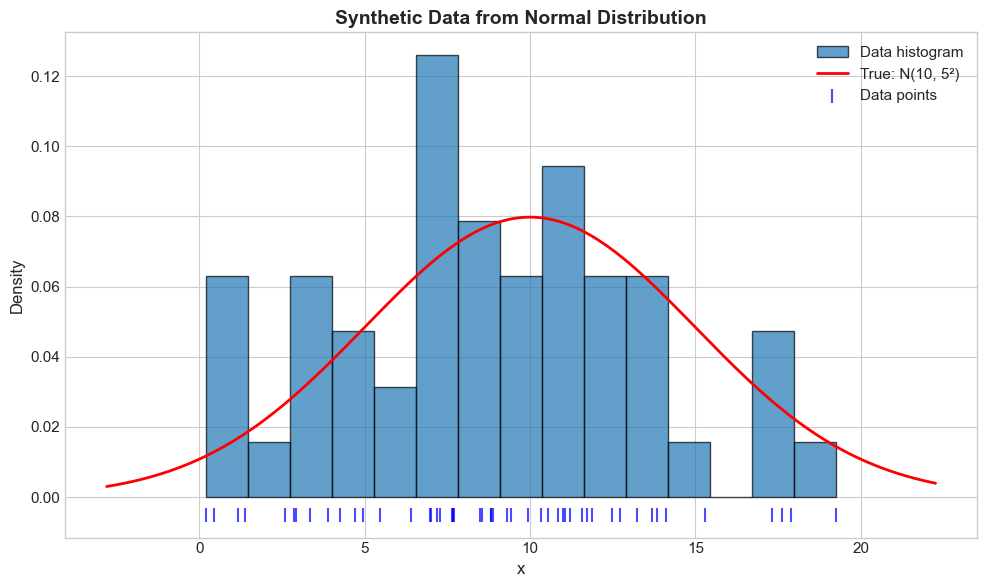

In [18]:
# Define the TRUE parameters (in real scenarios, these are unknown)
TRUE_MU = 10      # True mean
TRUE_SIGMA = 5    # True standard deviation
N_SAMPLES = 50    # Number of data points

# Generate synthetic data
data = np.random.normal(TRUE_MU, TRUE_SIGMA, N_SAMPLES)

print(f"Generated {N_SAMPLES} samples from Normal(μ={TRUE_MU}, σ={TRUE_SIGMA})")
print(f"\nSample statistics:")
print(f"  Sample mean:     {np.mean(data):.4f}")
print(f"  Sample std:      {np.std(data, ddof=1):.4f}")
print(f"  Sample min:      {np.min(data):.4f}")
print(f"  Sample max:      {np.max(data):.4f}")

# Visualize the data
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data, bins=15, density=True, alpha=0.7, edgecolor='black', label='Data histogram')

# Plot the true distribution
x_range = np.linspace(data.min() - 3, data.max() + 3, 200)
ax.plot(x_range, normal_pdf(x_range, TRUE_MU, TRUE_SIGMA), 'r-', linewidth=2, 
        label=f'True: N({TRUE_MU}, {TRUE_SIGMA}²)')

# Mark data points on x-axis
ax.scatter(data, np.zeros_like(data) - 0.005, marker='|', s=100, c='blue', alpha=0.7, label='Data points')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Synthetic Data from Normal Distribution', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

<a id='mean-exploration'></a>
## 5. Which Mean Best Explains the Data?

Let's explore how different values of $\mu$ affect how well the distribution fits our data. We'll keep $\sigma$ fixed at the true value for now.

**Key insight:** The distribution that places the data points in regions of highest density is the "best" fit.

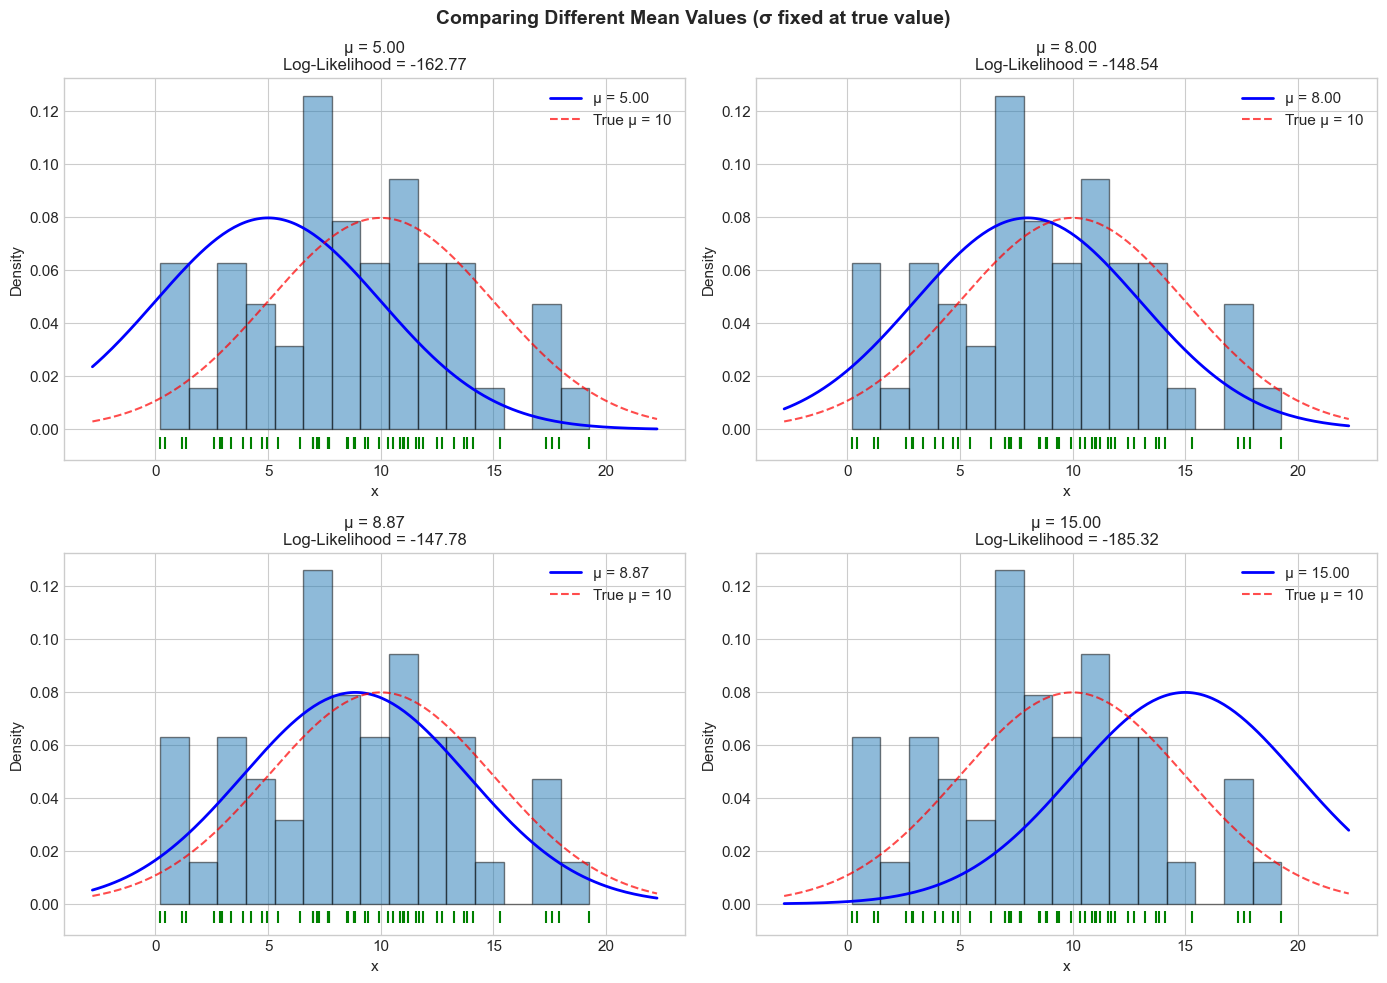

📊 Observation: The mean closest to the sample mean has the HIGHEST log-likelihood!


In [19]:
# Visualize how different means fit the data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Different candidate means to try
candidate_means = [5, 8, np.mean(data), 15]
x_range = np.linspace(data.min() - 3, data.max() + 3, 200)

for ax, mu_candidate in zip(axes, candidate_means):
    # Plot histogram
    ax.hist(data, bins=15, density=True, alpha=0.5, edgecolor='black')
    
    # Plot candidate distribution
    pdf_values = normal_pdf(x_range, mu_candidate, TRUE_SIGMA)
    ax.plot(x_range, pdf_values, 'b-', linewidth=2, label=f'μ = {mu_candidate:.2f}')
    
    # Plot true distribution for reference
    ax.plot(x_range, normal_pdf(x_range, TRUE_MU, TRUE_SIGMA), 'r--', 
            linewidth=1.5, alpha=0.7, label=f'True μ = {TRUE_MU}')
    
    # Mark data points
    ax.scatter(data, np.zeros_like(data) - 0.005, marker='|', s=80, c='green')
    
    # Compute likelihood for this mean
    likelihood = np.prod(normal_pdf(data, mu_candidate, TRUE_SIGMA))
    log_likelihood = np.sum(np.log(normal_pdf(data, mu_candidate, TRUE_SIGMA)))
    
    ax.set_title(f'μ = {mu_candidate:.2f}\nLog-Likelihood = {log_likelihood:.2f}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.suptitle('Comparing Different Mean Values (σ fixed at true value)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Observation: The mean closest to the sample mean has the HIGHEST log-likelihood!")

<a id='std-exploration'></a>
## 6. Which Standard Deviation Best Explains the Data?

Now let's fix $\mu$ at the sample mean and explore different values of $\sigma$.

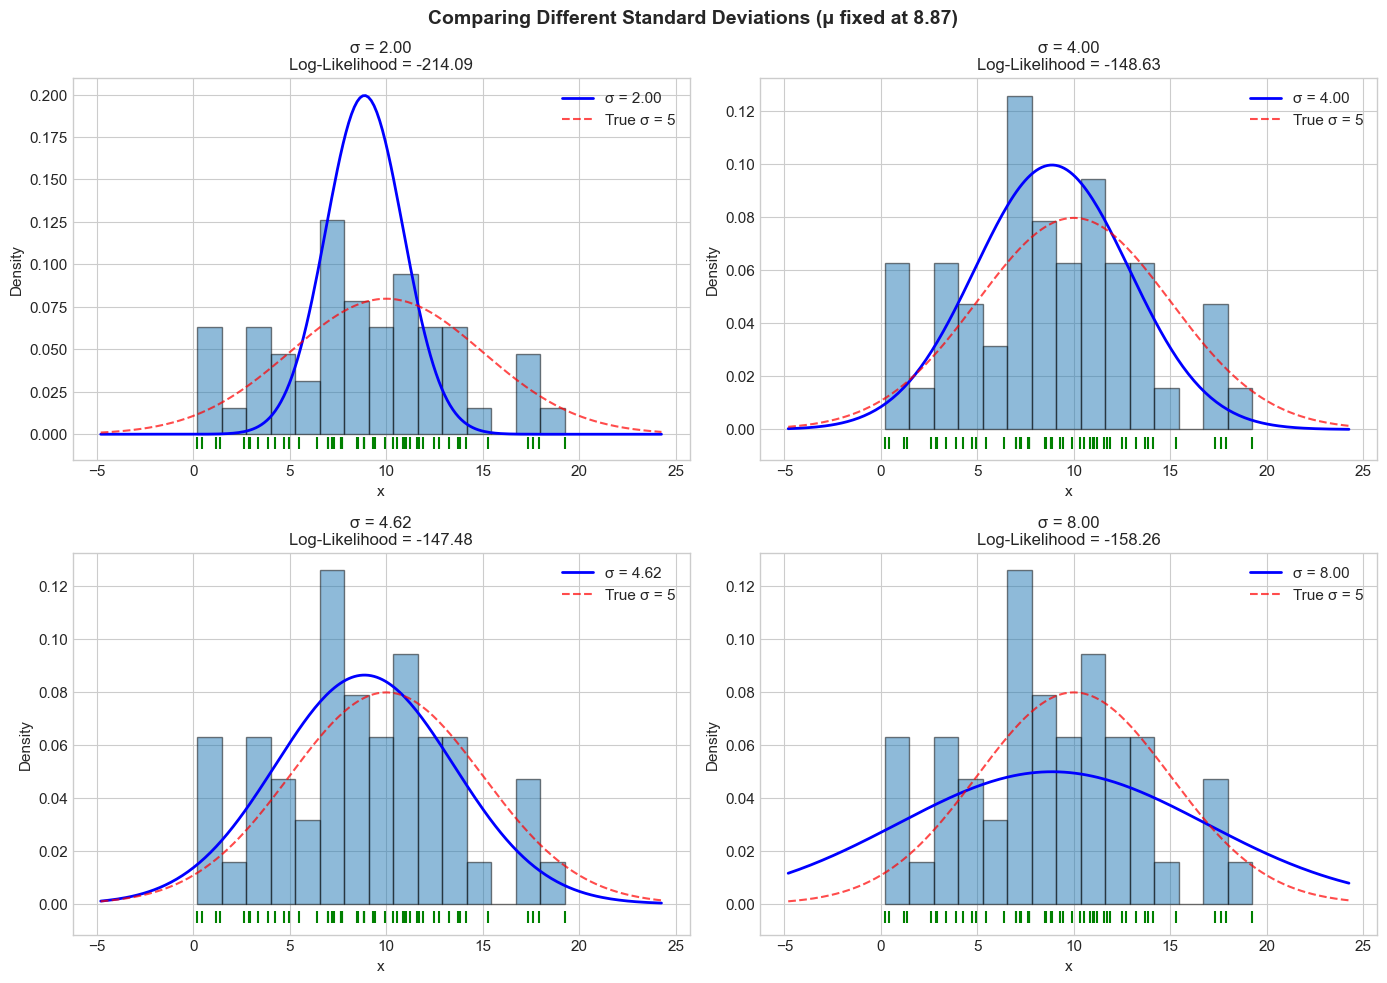

📊 Observation: σ too small → data in low-density tails → low likelihood
📊 Observation: σ too large → PDF too flat → low likelihood
📊 The optimal σ balances these effects!


In [20]:
# Visualize how different standard deviations fit the data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Use sample mean as mu
mu_fixed = np.mean(data)

# Different candidate standard deviations
candidate_sigmas = [2, 4, np.std(data, ddof=0), 8]
x_range = np.linspace(data.min() - 5, data.max() + 5, 200)

for ax, sigma_candidate in zip(axes, candidate_sigmas):
    # Plot histogram
    ax.hist(data, bins=15, density=True, alpha=0.5, edgecolor='black')
    
    # Plot candidate distribution
    pdf_values = normal_pdf(x_range, mu_fixed, sigma_candidate)
    ax.plot(x_range, pdf_values, 'b-', linewidth=2, label=f'σ = {sigma_candidate:.2f}')
    
    # Plot true distribution for reference
    ax.plot(x_range, normal_pdf(x_range, TRUE_MU, TRUE_SIGMA), 'r--', 
            linewidth=1.5, alpha=0.7, label=f'True σ = {TRUE_SIGMA}')
    
    # Mark data points
    ax.scatter(data, np.zeros_like(data) - 0.005, marker='|', s=80, c='green')
    
    # Compute log-likelihood for this sigma
    log_likelihood = np.sum(np.log(normal_pdf(data, mu_fixed, sigma_candidate)))
    
    ax.set_title(f'σ = {sigma_candidate:.2f}\nLog-Likelihood = {log_likelihood:.2f}', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')

plt.suptitle(f'Comparing Different Standard Deviations (μ fixed at {mu_fixed:.2f})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Observation: σ too small → data in low-density tails → low likelihood")
print("📊 Observation: σ too large → PDF too flat → low likelihood")
print("📊 The optimal σ balances these effects!")

<a id='interactive'></a>
## 7. Interactive Parameter Exploration

Use the sliders below to explore how $\mu$ and $\sigma$ affect the fit and log-likelihood.

**Goal:** Find the parameter values that maximize the log-likelihood!

In [21]:
def plot_interactive_normal(mu, sigma):
    """Interactive visualization of Normal distribution fit."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left plot: Distribution fit
    ax1 = axes[0]
    ax1.hist(data, bins=15, density=True, alpha=0.6, edgecolor='black', label='Data')
    
    x_range = np.linspace(data.min() - 5, data.max() + 5, 200)
    ax1.plot(x_range, normal_pdf(x_range, mu, sigma), 'b-', linewidth=2, 
             label=f'Candidate: N({mu:.1f}, {sigma:.1f}²)')
    ax1.plot(x_range, normal_pdf(x_range, TRUE_MU, TRUE_SIGMA), 'r--', 
             linewidth=1.5, alpha=0.7, label=f'True: N({TRUE_MU}, {TRUE_SIGMA}²)')
    
    ax1.scatter(data, np.zeros_like(data) - 0.005, marker='|', s=80, c='green')
    ax1.axvline(mu, color='blue', linestyle=':', alpha=0.5, label=f'μ = {mu:.1f}')
    
    ax1.set_xlabel('x')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution Fit')
    ax1.legend(loc='upper right')
    
    # Right plot: Log-likelihood contributions
    ax2 = axes[1]
    log_lik_contributions = np.log(normal_pdf(data, mu, sigma))
    colors = ['green' if ll > -5 else 'red' for ll in log_lik_contributions]
    ax2.bar(range(len(data)), log_lik_contributions, color=colors, alpha=0.7, edgecolor='black')
    ax2.axhline(0, color='black', linewidth=0.5)
    ax2.set_xlabel('Data Point Index')
    ax2.set_ylabel('Log-Likelihood Contribution')
    
    total_ll = np.sum(log_lik_contributions)
    ax2.set_title(f'Total Log-Likelihood = {total_ll:.2f}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Current parameters: μ = {mu:.2f}, σ = {sigma:.2f}")
    print(f"📊 Log-Likelihood: {total_ll:.4f}")
    print(f"📊 Sample mean: {np.mean(data):.4f}, Sample std (MLE): {np.std(data, ddof=0):.4f}")

# Create interactive widget
interact(plot_interactive_normal,
         mu=FloatSlider(min=0, max=20, step=0.5, value=10, description='μ:'),
         sigma=FloatSlider(min=1, max=10, step=0.5, value=5, description='σ:'))

interactive(children=(FloatSlider(value=10.0, description='μ:', max=20.0, step=0.5), FloatSlider(value=5.0, de…

<function __main__.plot_interactive_normal(mu, sigma)>

<a id='likelihood'></a>
## 8. Understanding Likelihood

<a id='lik-one'></a>
### 8.1 Likelihood of One Data Point

For a single observation $x_1$, the **likelihood** of parameters $\mu, \sigma$ given the data is simply the PDF evaluated at $x_1$:

$$L(\mu, \sigma | x_1) = f(x_1 | \mu, \sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_1-\mu)^2}{2\sigma^2}\right)$$

**Important distinction:**
- **PDF** $f(x|\mu,\sigma)$: Fixed parameters, variable $x$ → "What's the probability of seeing $x$?"
- **Likelihood** $L(\mu,\sigma|x)$: Fixed data, variable parameters → "How likely are these parameters given we saw $x$?" 

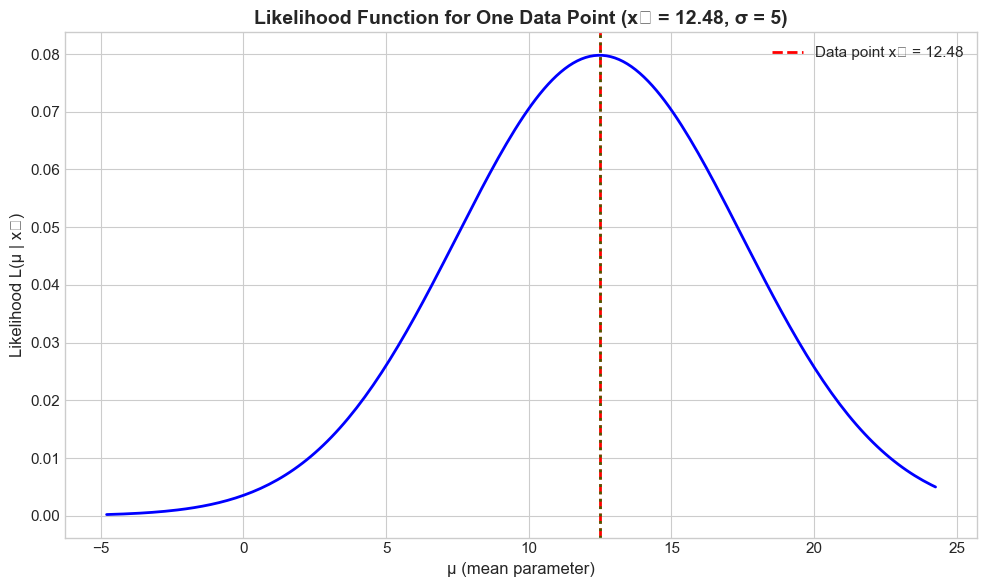

📊 The likelihood is maximized when μ = x₁ = 12.48
   This makes intuitive sense: the best estimate of the mean from one point is that point itself!


In [22]:
# Likelihood as a function of mu for one data point
x1 = data[0]  # First data point
sigma_fixed = TRUE_SIGMA

mu_range = np.linspace(data.min() - 5, data.max() + 5, 200)
likelihood_one = normal_pdf(x1, mu_range, sigma_fixed)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(mu_range, likelihood_one, 'b-', linewidth=2)
ax.axvline(x1, color='red', linestyle='--', linewidth=2, label=f'Data point x₁ = {x1:.2f}')
ax.axvline(x1, color='green', linestyle=':', linewidth=2, alpha=0.7)

ax.set_xlabel('μ (mean parameter)', fontsize=12)
ax.set_ylabel('Likelihood L(μ | x₁)', fontsize=12)
ax.set_title(f'Likelihood Function for One Data Point (x₁ = {x1:.2f}, σ = {sigma_fixed})', 
             fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"📊 The likelihood is maximized when μ = x₁ = {x1:.2f}")
print("   This makes intuitive sense: the best estimate of the mean from one point is that point itself!")

<a id='lik-multiple'></a>
### 8.2 Likelihood of Multiple Data Points

For **independent** observations $x_1, x_2, \ldots, x_n$, the joint likelihood is the **product** of individual likelihoods:

$$L(\mu, \sigma | x_1, x_2, \ldots, x_n) = \prod_{i=1}^{n} f(x_i | \mu, \sigma)$$

Let's see how the likelihood changes as we add more data points.

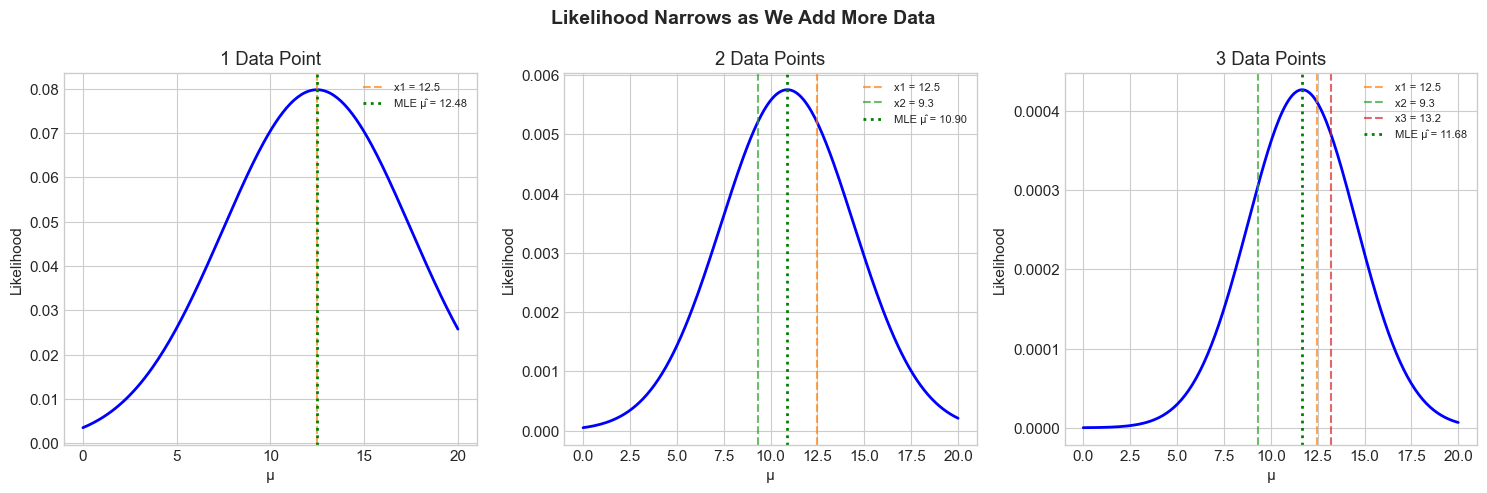

📊 Key insight: More data → narrower likelihood → more precise estimate!


In [23]:
# Likelihood for 1, 2, and 3 data points
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mu_range = np.linspace(0, 20, 200)
sigma_fixed = TRUE_SIGMA

for k, ax in enumerate(axes, 1):
    # Use first k data points
    subset = data[:k]
    
    # Compute likelihood for each mu
    likelihood = np.ones_like(mu_range)
    for x_i in subset:
        likelihood *= normal_pdf(x_i, mu_range, sigma_fixed)
    
    ax.plot(mu_range, likelihood, 'b-', linewidth=2)
    
    # Mark data points
    for i, x_i in enumerate(subset):
        ax.axvline(x_i, color=f'C{i+1}', linestyle='--', alpha=0.7, label=f'x{i+1} = {x_i:.1f}')
    
    # Mark MLE (sample mean)
    mle_mu = np.mean(subset)
    ax.axvline(mle_mu, color='green', linestyle=':', linewidth=2, label=f'MLE μ̂ = {mle_mu:.2f}')
    
    ax.set_xlabel('μ')
    ax.set_ylabel('Likelihood')
    ax.set_title(f'{k} Data Point{"s" if k > 1 else ""}')
    ax.legend(fontsize=8)

plt.suptitle('Likelihood Narrows as We Add More Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Key insight: More data → narrower likelihood → more precise estimate!")

<a id='lik-all'></a>
### 8.3 Likelihood of All Data Points

With all $n$ observations:

$$L(\mu, \sigma | \mathbf{x}) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

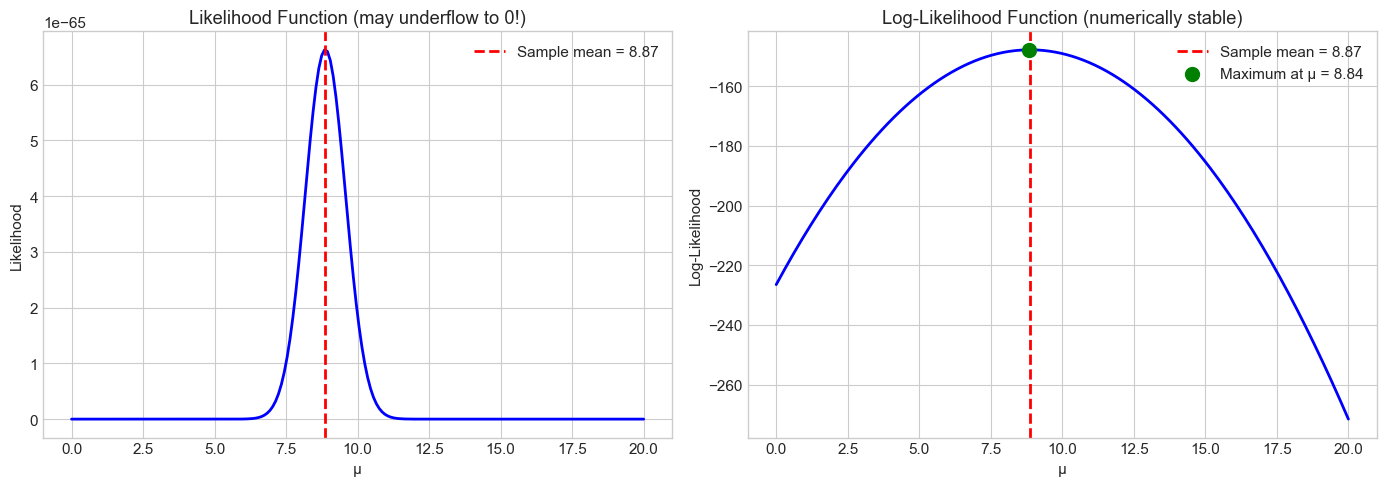

📊 Maximum likelihood estimate: μ̂ = 8.8442
📊 Sample mean: 8.8726
📊 They match! (within numerical precision)


In [24]:
# Compute likelihood and log-likelihood for all data as function of mu
mu_range = np.linspace(0, 20, 200)
sigma_fixed = TRUE_SIGMA

# Initialize arrays
likelihood_all = np.ones_like(mu_range)
log_likelihood_all = np.zeros_like(mu_range)

for x_i in data:
    likelihood_all *= normal_pdf(x_i, mu_range, sigma_fixed)
    log_likelihood_all += np.log(normal_pdf(x_i, mu_range, sigma_fixed))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Likelihood (often underflows!)
ax1 = axes[0]
ax1.plot(mu_range, likelihood_all, 'b-', linewidth=2)
ax1.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Sample mean = {np.mean(data):.2f}')
ax1.set_xlabel('μ')
ax1.set_ylabel('Likelihood')
ax1.set_title('Likelihood Function (may underflow to 0!)')
ax1.legend()

# Right: Log-Likelihood (numerically stable)
ax2 = axes[1]
ax2.plot(mu_range, log_likelihood_all, 'b-', linewidth=2)
ax2.axvline(np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Sample mean = {np.mean(data):.2f}')
max_ll_idx = np.argmax(log_likelihood_all)
ax2.scatter(mu_range[max_ll_idx], log_likelihood_all[max_ll_idx], color='green', s=100, 
            zorder=5, label=f'Maximum at μ = {mu_range[max_ll_idx]:.2f}')
ax2.set_xlabel('μ')
ax2.set_ylabel('Log-Likelihood')
ax2.set_title('Log-Likelihood Function (numerically stable)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"📊 Maximum likelihood estimate: μ̂ = {mu_range[max_ll_idx]:.4f}")
print(f"📊 Sample mean: {np.mean(data):.4f}")
print("📊 They match! (within numerical precision)")

<a id='why-log'></a>
## 9. Why Use Log-Likelihood?

### The Problem with Raw Likelihood

For $n$ observations, the likelihood is a product of $n$ small numbers:

$$L = \prod_{i=1}^{n} f(x_i) \approx (0.1)^{50} = 10^{-50}$$

This causes **numerical underflow** (computer represents it as 0).

### The Solution: Log-Likelihood

$$\ell = \log L = \sum_{i=1}^{n} \log f(x_i)$$

| Raw Likelihood | Log-Likelihood |
|----------------|----------------|
| Product of small numbers | Sum of negative numbers |
| Underflows to 0 | Numerically stable |
| Hard to differentiate | Easy to differentiate |
| $\arg\max L(\theta)$ | $= \arg\max \ell(\theta)$ |

**Key insight:** Since $\log$ is monotonic, maximizing $\ell$ gives the same answer as maximizing $L$!

In [25]:
# Demonstrate numerical underflow
np.random.seed(42)
test_samples = np.random.normal(0, 1, 100)

# Try to compute raw likelihood
raw_likelihood = 1.0
for x in test_samples:
    raw_likelihood *= stats.norm.pdf(x, 0, 1)

# Compute log-likelihood
log_likelihood = np.sum(stats.norm.logpdf(test_samples, 0, 1))

print("🔢 Numerical Stability Demonstration")
print("=" * 50)
print(f"Sample size: {len(test_samples)}")
print(f"\nRaw Likelihood (product): {raw_likelihood}")
print(f"Log-Likelihood (sum):     {log_likelihood:.4f}")
print(f"\n⚠️  The raw likelihood underflowed to {raw_likelihood}!")
print("✓  Log-likelihood remains stable and usable.")

🔢 Numerical Stability Demonstration
Sample size: 100

Raw Likelihood (product): 1.3374534290104539e-58
Log-Likelihood (sum):     -133.2592

⚠️  The raw likelihood underflowed to 1.3374534290104539e-58!
✓  Log-likelihood remains stable and usable.


<a id='log-derivation'></a>
## 10. Log-Likelihood Derivation

### Step 1: Write the Likelihood

For i.i.d. observations $x_1, x_2, \ldots, x_n$ from $N(\mu, \sigma^2)$:

$$L(\mu, \sigma | x_1, \ldots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

### Step 2: Take the Logarithm

$$\ell(\mu, \sigma) = \log L = \sum_{i=1}^{n} \log\left[\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)\right]$$

### Step 3: Use Log Properties

Using $\log(ab) = \log a + \log b$ and $\log(e^x) = x$:

$$\ell(\mu, \sigma) = \sum_{i=1}^{n} \left[-\frac{1}{2}\log(2\pi\sigma^2) - \frac{(x_i-\mu)^2}{2\sigma^2}\right]$$

### Step 4: Simplify

$$\ell(\mu, \sigma) = -\frac{n}{2}\log(2\pi) - n\log(\sigma) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2$$

Or equivalently:

$$\boxed{\ell(\mu, \sigma) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2}$$

---

<a id='numerical'></a>
## 11. Finding the MLE Numerically

We can use numerical optimization to find the parameters that maximize the log-likelihood (or equivalently, minimize the negative log-likelihood).

In [26]:
def neg_log_likelihood(params, X):
    """
    Computes the NEGATIVE log-likelihood for Normal distribution.
    (Negative because scipy minimizes, but we want to maximize)
    
    Parameters:
    -----------
    params : array-like
        [mu, sigma] - the parameters to optimize
    X : array-like
        The observed data
    
    Returns:
    --------
    float
        The negative log-likelihood
    """
    mu, sigma = params
    
    # Ensure sigma is positive
    if sigma <= 0:
        return np.inf
    
    n = len(X)
    
    # Log-likelihood formula
    log_lik = -n/2 * np.log(2 * np.pi * sigma**2) - np.sum((X - mu)**2) / (2 * sigma**2)
    
    return -log_lik  # Return negative for minimization

# Initial guess
initial_params = [0, 1]

# Optimize using L-BFGS-B (allows bounds)
result = minimize(neg_log_likelihood, initial_params, args=(data,), 
                  method='L-BFGS-B', bounds=[(None, None), (0.01, None)])

mu_mle_num = result.x[0]
sigma_mle_num = result.x[1]

print("=" * 60)
print("NUMERICAL OPTIMIZATION RESULTS (SciPy)")
print("=" * 60)
print(f"Estimated μ (mean):      {mu_mle_num:.6f}")
print(f"Estimated σ (std dev):   {sigma_mle_num:.6f}")
print(f"Maximum log-likelihood:  {-result.fun:.4f}")
print(f"Optimization converged:  {result.success}")
print("\nComparison:")
print(f"  Sample mean:           {np.mean(data):.6f}")
print(f"  Sample std (MLE):      {np.std(data, ddof=0):.6f}")
print(f"  Sample std (unbiased): {np.std(data, ddof=1):.6f}")
print(f"\nTrue parameters: μ = {TRUE_MU}, σ = {TRUE_SIGMA}")
print("=" * 60)

NUMERICAL OPTIMIZATION RESULTS (SciPy)
Estimated μ (mean):      8.872630
Estimated σ (std dev):   4.621424
Maximum log-likelihood:  -147.4821
Optimization converged:  True

Comparison:
  Sample mean:           8.872630
  Sample std (MLE):      4.621425
  Sample std (unbiased): 4.668344

True parameters: μ = 10, σ = 5


<a id='analytical'></a>
## 12. Analytical Solution (Closed-Form MLE)

For the Normal distribution, we can derive the MLE analytically by setting the derivatives equal to zero.

### Step 1: Derivative with respect to $\mu$

$$\frac{\partial \ell}{\partial \mu} = \frac{1}{\sigma^2}\sum_{i=1}^{n}(x_i - \mu) = 0$$

**Solving for $\mu$:**

$$\sum_{i=1}^{n}(x_i - \mu) = 0$$
$$\sum_{i=1}^{n}x_i - n\mu = 0$$

$$\boxed{\hat{\mu}_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}x_i = \bar{x}}$$

**Result: The MLE for $\mu$ is the sample mean!**

---

### Step 2: Derivative with respect to $\sigma$

$$\frac{\partial \ell}{\partial \sigma} = -\frac{n}{\sigma} + \frac{1}{\sigma^3}\sum_{i=1}^{n}(x_i - \mu)^2 = 0$$

**Solving for $\sigma^2$:**

$$\frac{n}{\sigma} = \frac{1}{\sigma^3}\sum_{i=1}^{n}(x_i - \mu)^2$$
$$n\sigma^2 = \sum_{i=1}^{n}(x_i - \mu)^2$$

$$\boxed{\hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

**Result: The MLE for $\sigma^2$ is the sample variance with divisor $n$ (not $n-1$)!**

---

### Verification

In [27]:
# Analytical MLE formulas
mu_mle_analytical = np.mean(data)
sigma2_mle_analytical = np.var(data, ddof=0)  # ddof=0 means divide by n
sigma_mle_analytical = np.sqrt(sigma2_mle_analytical)

print("=" * 60)
print("ANALYTICAL MLE FORMULAS")
print("=" * 60)
print(f"\nMLE for μ:  μ̂ = (1/n)Σxᵢ = {mu_mle_analytical:.6f}")
print(f"MLE for σ²: σ̂² = (1/n)Σ(xᵢ-μ̂)² = {sigma2_mle_analytical:.6f}")
print(f"MLE for σ:  σ̂ = √(σ̂²) = {sigma_mle_analytical:.6f}")

print("\n" + "-" * 60)
print("COMPARISON: Numerical vs Analytical")
print("-" * 60)
print(f"{'Method':<25} {'μ':<15} {'σ':<15}")
print(f"{'Numerical (SciPy)':<25} {mu_mle_num:<15.6f} {sigma_mle_num:<15.6f}")
print(f"{'Analytical':<25} {mu_mle_analytical:<15.6f} {sigma_mle_analytical:<15.6f}")
print(f"{'True':<25} {TRUE_MU:<15.6f} {TRUE_SIGMA:<15.6f}")
print("=" * 60)

print("\n✓ Numerical and analytical solutions match perfectly!")

ANALYTICAL MLE FORMULAS

MLE for μ:  μ̂ = (1/n)Σxᵢ = 8.872630
MLE for σ²: σ̂² = (1/n)Σ(xᵢ-μ̂)² = 21.357566
MLE for σ:  σ̂ = √(σ̂²) = 4.621425

------------------------------------------------------------
COMPARISON: Numerical vs Analytical
------------------------------------------------------------
Method                    μ               σ              
Numerical (SciPy)         8.872630        4.621424       
Analytical                8.872630        4.621425       
True                      10.000000       5.000000       

✓ Numerical and analytical solutions match perfectly!


<a id='surface'></a>
## 13. 2D Likelihood Surface

Let's visualize the log-likelihood as a function of both $\mu$ and $\sigma$ simultaneously.

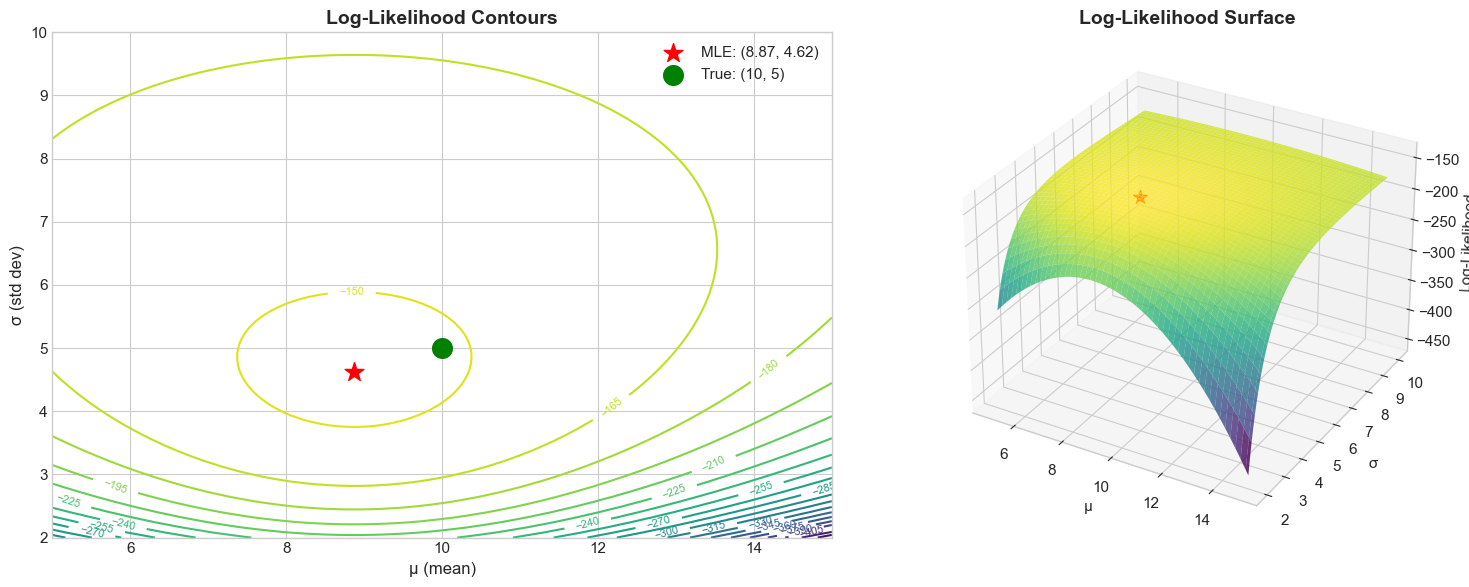

📊 The MLE is at the peak of the log-likelihood surface!
📊 The contours show elliptical shape → μ and σ are (approximately) independent.


In [28]:
# Create 2D grid for likelihood surface
mu_grid = np.linspace(5, 15, 100)
sigma_grid = np.linspace(2, 10, 100)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)

# Compute log-likelihood at each point
LOG_LIK = np.zeros_like(MU)
for i in range(len(sigma_grid)):
    for j in range(len(mu_grid)):
        LOG_LIK[i, j] = -neg_log_likelihood([MU[i, j], SIGMA[i, j]], data)

# Create figure with contour plot and 3D surface
fig = plt.figure(figsize=(16, 6))

# Contour plot
ax1 = fig.add_subplot(121)
contours = ax1.contour(MU, SIGMA, LOG_LIK, levels=20, cmap='viridis')
ax1.clabel(contours, inline=True, fontsize=8)
ax1.scatter(mu_mle_analytical, sigma_mle_analytical, color='red', s=200, marker='*', 
            label=f'MLE: ({mu_mle_analytical:.2f}, {sigma_mle_analytical:.2f})', zorder=5)
ax1.scatter(TRUE_MU, TRUE_SIGMA, color='green', s=200, marker='o', 
            label=f'True: ({TRUE_MU}, {TRUE_SIGMA})', zorder=5)
ax1.set_xlabel('μ (mean)', fontsize=12)
ax1.set_ylabel('σ (std dev)', fontsize=12)
ax1.set_title('Log-Likelihood Contours', fontsize=14, fontweight='bold')
ax1.legend()

# 3D surface
ax2 = fig.add_subplot(122, projection='3d')
surf = ax2.plot_surface(MU, SIGMA, LOG_LIK, cmap='viridis', alpha=0.8)
ax2.scatter([mu_mle_analytical], [sigma_mle_analytical], 
            [-neg_log_likelihood([mu_mle_analytical, sigma_mle_analytical], data)],
            color='red', s=100, marker='*', label='MLE')
ax2.set_xlabel('μ')
ax2.set_ylabel('σ')
ax2.set_zlabel('Log-Likelihood')
ax2.set_title('Log-Likelihood Surface', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("📊 The MLE is at the peak of the log-likelihood surface!")
print("📊 The contours show elliptical shape → μ and σ are (approximately) independent.")

<a id='diagnostics'></a>
## 14. Model Diagnostics

Before trusting our MLE estimates, we should check if the Normal distribution assumption is reasonable.

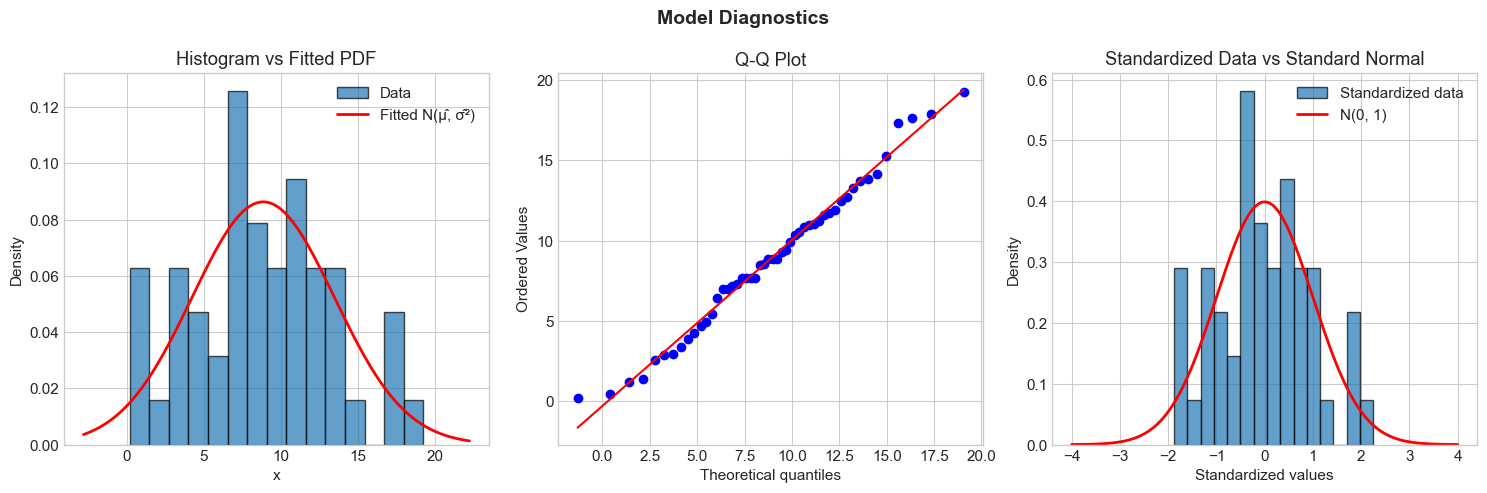


📊 Shapiro-Wilk Normality Test:
   Test statistic: 0.9827
   p-value: 0.6722
   ✓ Cannot reject normality (p > 0.05)


In [29]:
# Model diagnostics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Histogram with fitted distribution
ax1 = axes[0]
ax1.hist(data, bins=15, density=True, alpha=0.7, edgecolor='black', label='Data')
x_range = np.linspace(data.min() - 3, data.max() + 3, 200)
ax1.plot(x_range, normal_pdf(x_range, mu_mle_analytical, sigma_mle_analytical), 
         'r-', linewidth=2, label='Fitted N(μ̂, σ̂²)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.set_title('Histogram vs Fitted PDF')
ax1.legend()

# 2. Q-Q Plot
ax2 = axes[1]
stats.probplot(data, dist="norm", sparams=(mu_mle_analytical, sigma_mle_analytical), plot=ax2)
ax2.set_title('Q-Q Plot')

# 3. Standardized residuals
ax3 = axes[2]
standardized = (data - mu_mle_analytical) / sigma_mle_analytical
ax3.hist(standardized, bins=15, density=True, alpha=0.7, edgecolor='black', label='Standardized data')
z_range = np.linspace(-4, 4, 200)
ax3.plot(z_range, stats.norm.pdf(z_range, 0, 1), 'r-', linewidth=2, label='N(0, 1)')
ax3.set_xlabel('Standardized values')
ax3.set_ylabel('Density')
ax3.set_title('Standardized Data vs Standard Normal')
ax3.legend()

plt.suptitle('Model Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Shapiro-Wilk test for normality
stat, p_value = stats.shapiro(data)
print(f"\n📊 Shapiro-Wilk Normality Test:")
print(f"   Test statistic: {stat:.4f}")
print(f"   p-value: {p_value:.4f}")
if p_value > 0.05:
    print("   ✓ Cannot reject normality (p > 0.05)")
else:
    print("   ⚠️ Evidence against normality (p < 0.05)")

<a id='summary'></a>
## 18. Summary & Key Takeaways

### MLE for Normal Distribution

| Parameter | MLE Formula | Properties |
|-----------|-------------|------------|
| Mean $\mu$ | $\hat{\mu} = \bar{x} = \frac{1}{n}\sum x_i$ | Unbiased, efficient |
| Variance $\sigma^2$ | $\hat{\sigma}^2 = \frac{1}{n}\sum(x_i - \bar{x})^2$ | Biased (underestimates) |



### Formulas Summary

$$\ell(\mu, \sigma) = -\frac{n}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^{n}(x_i-\mu)^2$$

$$\hat{\mu}_{\text{MLE}} = \bar{x}, \quad \hat{\sigma}^2_{\text{MLE}} = \frac{1}{n}\sum(x_i - \bar{x})^2$$

$$\text{SE}(\hat{\mu}) = \frac{\sigma}{\sqrt{n}}, \quad \text{SE}(\hat{\sigma}) \approx \frac{\sigma}{\sqrt{2n}}$$

---

**End of Notebook**  
*Course: TTK 4260 - Multivariate Data Analysis and Machine Learning*